# Notebook 05 — Clustering intermedio: continuas robustas + binarias de oferta

**Autora:** Victoria Di Liscia
**Programa:** Maestría en Explotación de Datos y Descubrimiento del Conocimiento — FCEN, UBA

## Motivación

El notebook 04 mostró que el cambio metodológico (log + RobustScaler + GMM) mejoró el silhouette (0.243 → 0.275) **pero perdió la dimensión de "modelo de negocio retail"** que aportaban las 11 binarias de oferta. La partición quedó dominada por rentabilidad (PC1 = 47% de varianza cargando fuerte en ROA), y el modelo aisló sólo a los 4 bancos 100% digitales.

Este notebook combina lo mejor de los dos:
- **10 continuas** con `log1p` sobre las sesgadas + RobustScaler (del notebook 04).
- **11 binarias** de oferta concatenadas tal cual (del notebook 03, que ya son 0/1).
- **Dos ponderaciones** de las binarias (1.0 y 0.5) para evaluar sensibilidad al peso relativo de la dimensión de oferta.

La hipótesis es que recuperar las binarias va a "abrir" otra vez los perfiles minorista vs mayorista, mientras que las transformaciones robustas mantienen al outlier bajo control.

## 1. Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ROOT = Path().resolve().parent if Path().resolve().name == "notebooks" else Path().resolve()
PROCESSED = ROOT / "data" / "processed"

SEED = 42
np.random.seed(SEED)
print(f"ROOT: {ROOT}")

ROOT: /Users/victoria/Documents/Maestria/tesis-perfiles-bancarios


## 2. Preparación de datos

Mismo universo que los notebooks 03 y 04 (52 bancos, promedio de los 3 cortes).

In [2]:
panel = pd.read_csv(PROCESSED / "panel_ratios.csv")

EXCLUIDOS = {131: "Bank of China", 165: "JPMorgan", 266: "BNP Paribas", 331: "Cetelem"}
panel = panel[~panel["codigo_entidad"].isin(EXCLUIDOS)].copy()

panel["log_activo"] = np.log(panel["activo"])
panel["titulos_sobre_activo"] = panel["TÍTULOS PÚBLICOS Y PRIVADOS"].abs() / panel["activo"]
panel["patrimonio_sobre_activo"] = panel["patrimonio"].abs() / panel["activo"]
panel["log_activo_por_empleado"] = np.log(panel["activo_por_empleado"].clip(lower=1))

FEATURES_CONT = [
    "log_activo", "prestamos_sobre_activo", "titulos_sobre_activo",
    "depositos_sobre_activo", "patrimonio_sobre_activo", "roa",
    "liquidez", "eficiencia", "cartera_irregular", "log_activo_por_empleado",
]

FEATURES_BIN = [
    "ofrece_hipoteca", "hipoteca_uva", "ofrece_personal", "ofrece_prendario",
    "ofrece_pfijo", "pfijo_uva", "ofrece_paquete", "paquete_tiene_premium",
    "ofrece_tarjeta", "tarjeta_tiene_premium", "caja_apertura_simplificada",
]

META = ["codigo_entidad", "nombre_banco", "tipo_entidad"]

df = panel.groupby(META)[FEATURES_CONT + FEATURES_BIN].mean().reset_index()

imp = SimpleImputer(strategy="median")
df_imp = df.copy()
df_imp[FEATURES_CONT + FEATURES_BIN] = imp.fit_transform(df[FEATURES_CONT + FEATURES_BIN])

print(f"Dataset: {df_imp.shape[0]} bancos × {len(FEATURES_CONT)} continuas + {len(FEATURES_BIN)} binarias")

Dataset: 52 bancos × 10 continuas + 11 binarias


## 3. Construcción del espacio mixto

Procesamos las continuas como en el notebook 04 (log + RobustScaler), pero después concatenamos las binarias sin escalar.

**¿Por qué dos ponderaciones?** Después del scaler robusto, las continuas tienen IQR ≈ 1. Las binarias tienen varianza ≈ 0.25 (porque la mayoría son ~50/50). Si simplemente las concatenamos:

- **Peso 1.0**: cada binaria contribuye ~25% del peso de una continua, pero hay 11 binarias → en conjunto compiten fuerte con las 10 continuas.
- **Peso 0.5**: las binarias quedan a la mitad del peso → más espacio para que las continuas dominen.

Comparamos ambas para ver cuál da mejor estructura.

In [3]:
LOG_VARS = ["liquidez", "cartera_irregular", "eficiencia"]

# 1) Bloque continuo: log + RobustScaler
df_cont = df_imp[FEATURES_CONT].copy()
for v in LOG_VARS:
    df_cont[v] = np.log1p(df_cont[v])

scaler = RobustScaler()
X_cont = scaler.fit_transform(df_cont)

# 2) Bloque binario tal cual
X_bin = df_imp[FEATURES_BIN].values.astype(float)

print(f"X_cont shape: {X_cont.shape}")
print(f"X_bin  shape: {X_bin.shape}")
print(f"\nVarianza por feature:")
print(f"  continuas (después de escalar): media = {X_cont.var(axis=0).mean():.3f}, rango = [{X_cont.var(axis=0).min():.3f}, {X_cont.var(axis=0).max():.3f}]")
print(f"  binarias (sin escalar)        : media = {X_bin.var(axis=0).mean():.3f}, rango = [{X_bin.var(axis=0).min():.3f}, {X_bin.var(axis=0).max():.3f}]")

X_cont shape: (52, 10)
X_bin  shape: (52, 11)

Varianza por feature:
  continuas (después de escalar): media = 1.188, rango = [0.525, 4.539]
  binarias (sin escalar)        : media = 0.210, rango = [0.071, 0.250]


### 3.1 Construcción de las dos matrices ponderadas

In [4]:
# Versión A: peso 1.0 en las binarias
X_A = np.hstack([X_cont, X_bin * 1.0])

# Versión B: peso 0.5 en las binarias
X_B = np.hstack([X_cont, X_bin * 0.5])

print(f"X_A (peso 1.0) shape: {X_A.shape}")
print(f"X_B (peso 0.5) shape: {X_B.shape}")

X_A (peso 1.0) shape: (52, 21)
X_B (peso 0.5) shape: (52, 21)


## 4. PCA exploratorio

Comparamos las dos versiones lado a lado para ver cómo cambia la estructura de varianza.

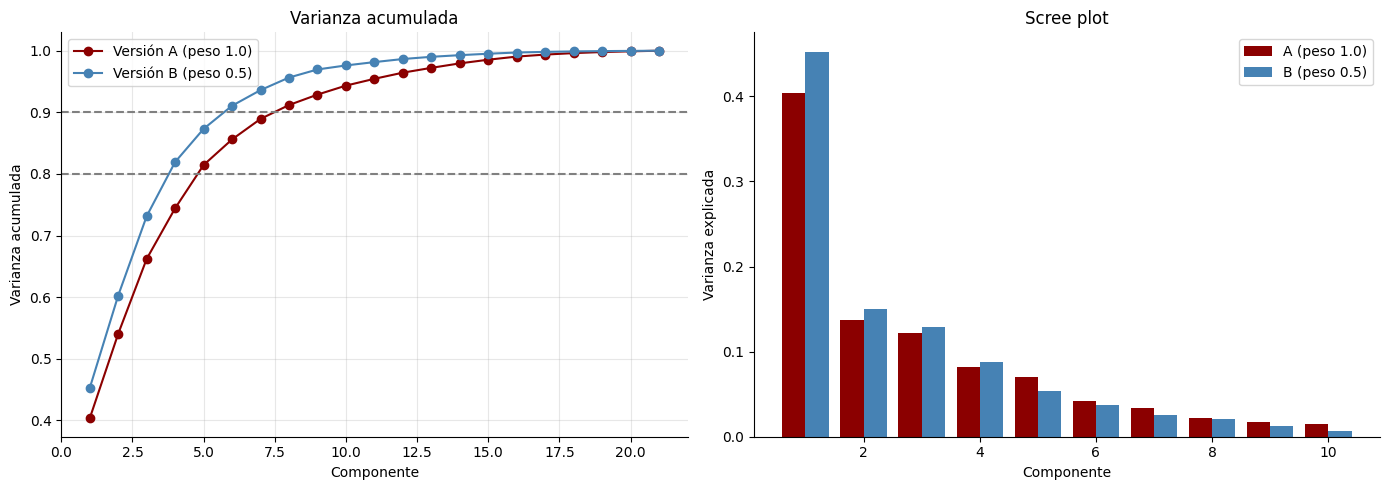

Varianza explicada (primeros 6 componentes):

  PC      A (peso 1.0)   B (peso 0.5)
  PC1           40.3 %         45.3 %
  PC2           13.7 %         15.0 %
  PC3           12.1 %         12.9 %
  PC4            8.2 %          8.8 %
  PC5            7.0 %          5.4 %
  PC6            4.2 %          3.7 %


In [5]:
pca_A = PCA().fit(X_A)
pca_B = PCA().fit(X_B)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(pca_A.explained_variance_ratio_) + 1), np.cumsum(pca_A.explained_variance_ratio_), "o-", label="Versión A (peso 1.0)", color="darkred")
axes[0].plot(range(1, len(pca_B.explained_variance_ratio_) + 1), np.cumsum(pca_B.explained_variance_ratio_), "o-", label="Versión B (peso 0.5)", color="steelblue")
axes[0].axhline(0.8, ls="--", color="gray"); axes[0].axhline(0.9, ls="--", color="gray")
axes[0].set_xlabel("Componente"); axes[0].set_ylabel("Varianza acumulada"); axes[0].set_title("Varianza acumulada")
axes[0].legend(); axes[0].grid(alpha=0.3)

x_pos = np.arange(1, 11)
width = 0.4
axes[1].bar(x_pos - width/2, pca_A.explained_variance_ratio_[:10], width, label="A (peso 1.0)", color="darkred")
axes[1].bar(x_pos + width/2, pca_B.explained_variance_ratio_[:10], width, label="B (peso 0.5)", color="steelblue")
axes[1].set_xlabel("Componente"); axes[1].set_ylabel("Varianza explicada"); axes[1].set_title("Scree plot")
axes[1].legend()
plt.tight_layout(); plt.show()

print("Varianza explicada (primeros 6 componentes):\n")
print(f"  {'PC':<5} {'A (peso 1.0)':>14} {'B (peso 0.5)':>14}")
for i in range(6):
    print(f"  PC{i+1:<3} {pca_A.explained_variance_ratio_[i]*100:>12.1f} % {pca_B.explained_variance_ratio_[i]*100:>12.1f} %")

### 4.1 Loadings de los primeros componentes

In [6]:
all_feats = FEATURES_CONT + FEATURES_BIN

loadings_A = pd.DataFrame(pca_A.components_[:4].T, index=all_feats, columns=[f"PC{i+1}" for i in range(4)])
loadings_B = pd.DataFrame(pca_B.components_[:4].T, index=all_feats, columns=[f"PC{i+1}" for i in range(4)])

print("Versión A (peso 1.0) — loadings:\n")
print(loadings_A.round(3).to_string())
print("\n\nVersión B (peso 0.5) — loadings:\n")
print(loadings_B.round(3).to_string())

Versión A (peso 1.0) — loadings:

                              PC1    PC2    PC3    PC4
log_activo                  0.178 -0.228 -0.034  0.274
prestamos_sobre_activo      0.043 -0.378  0.202 -0.253
titulos_sobre_activo        0.073  0.413  0.009  0.215
depositos_sobre_activo      0.039 -0.185 -0.439  0.204
patrimonio_sobre_activo    -0.067  0.584  0.277 -0.192
roa                         0.871  0.017  0.134 -0.275
liquidez                   -0.177 -0.369  0.724  0.148
eficiencia                 -0.347 -0.086 -0.195 -0.320
cartera_irregular          -0.057 -0.131 -0.000 -0.428
log_activo_por_empleado     0.141 -0.084  0.054  0.477
ofrece_hipoteca             0.075 -0.102 -0.105  0.030
hipoteca_uva                0.061 -0.104 -0.100  0.040
ofrece_personal            -0.018 -0.054 -0.067 -0.155
ofrece_prendario            0.046 -0.074 -0.038 -0.096
ofrece_pfijo                0.003  0.011 -0.117 -0.095
pfijo_uva                   0.014 -0.130 -0.209 -0.028
ofrece_paquete              0.0

## 5. K-Means k=3 — baseline en ambas versiones

Antes de pasar a GMM, corremos K-Means en cada versión para ver si una pondera la estructura mejor que la otra.

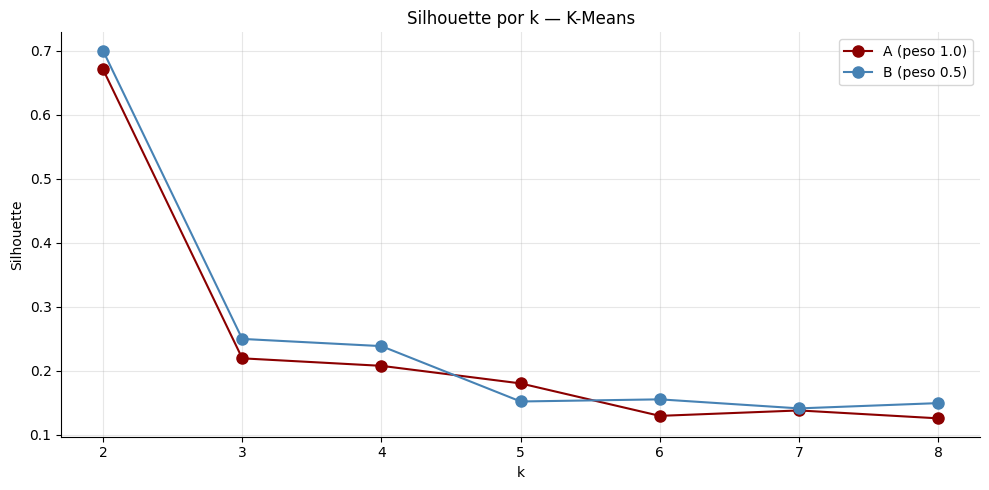

k      A (peso 1.0)   B (peso 0.5)
k=2            0.670          0.700
k=3            0.219          0.249
k=4            0.207          0.238
k=5            0.180          0.152
k=6            0.129          0.155
k=7            0.138          0.141
k=8            0.125          0.149


In [7]:
def silhouette_sweep(X, k_range=range(2, 9)):
    out = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=100)
        labels = km.fit_predict(X)
        out[k] = silhouette_score(X, labels)
    return out

sil_A = silhouette_sweep(X_A)
sil_B = silhouette_sweep(X_B)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(sil_A.keys()), list(sil_A.values()), "o-", label="A (peso 1.0)", color="darkred", markersize=8)
ax.plot(list(sil_B.keys()), list(sil_B.values()), "o-", label="B (peso 0.5)", color="steelblue", markersize=8)
ax.set_xlabel("k"); ax.set_ylabel("Silhouette"); ax.set_title("Silhouette por k — K-Means")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'k':<4} {'A (peso 1.0)':>14} {'B (peso 0.5)':>14}")
for k in sil_A:
    print(f"k={k:<3} {sil_A[k]:>14.3f} {sil_B[k]:>14.3f}")

In [8]:
# Ajuste final con k=3 para ambas versiones
km_A = KMeans(n_clusters=3, random_state=SEED, n_init=100)
df_imp["cluster_km_A"] = km_A.fit_predict(X_A)
sil_km_A = silhouette_score(X_A, df_imp["cluster_km_A"])

km_B = KMeans(n_clusters=3, random_state=SEED, n_init=100)
df_imp["cluster_km_B"] = km_B.fit_predict(X_B)
sil_km_B = silhouette_score(X_B, df_imp["cluster_km_B"])

print(f"K-Means k=3 — Versión A (peso 1.0)")
print(f"  Silhouette: {sil_km_A:.3f}")
print(f"  Distribución: {df_imp['cluster_km_A'].value_counts().sort_index().tolist()}")
print()
print(f"K-Means k=3 — Versión B (peso 0.5)")
print(f"  Silhouette: {sil_km_B:.3f}")
print(f"  Distribución: {df_imp['cluster_km_B'].value_counts().sort_index().tolist()}")

K-Means k=3 — Versión A (peso 1.0)
  Silhouette: 0.219
  Distribución: [36, 1, 15]

K-Means k=3 — Versión B (peso 0.5)
  Silhouette: 0.249
  Distribución: [15, 1, 36]


## 6. GMM k=3 — modelo principal en ambas versiones

In [9]:
def fit_gmm(X, k=3):
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=SEED, n_init=20)
    gmm.fit(X)
    labels = gmm.predict(X)
    probs = gmm.predict_proba(X).max(axis=1)
    return labels, probs, gmm.bic(X), silhouette_score(X, labels)

# Versión A
labels_A, probs_A, bic_A, sil_gmm_A = fit_gmm(X_A)
df_imp["cluster_gmm_A"] = labels_A
df_imp["prob_gmm_A"] = probs_A

# Versión B
labels_B, probs_B, bic_B, sil_gmm_B = fit_gmm(X_B)
df_imp["cluster_gmm_B"] = labels_B
df_imp["prob_gmm_B"] = probs_B

print(f"GMM k=3 — Versión A (peso 1.0)")
print(f"  Silhouette: {sil_gmm_A:.3f}")
print(f"  BIC       : {bic_A:.1f}")
print(f"  Distribución: {pd.Series(labels_A).value_counts().sort_index().tolist()}")
print(f"  Ambiguos (p < 0.7): {(probs_A < 0.7).sum()}")
print()
print(f"GMM k=3 — Versión B (peso 0.5)")
print(f"  Silhouette: {sil_gmm_B:.3f}")
print(f"  BIC       : {bic_B:.1f}")
print(f"  Distribución: {pd.Series(labels_B).value_counts().sort_index().tolist()}")
print(f"  Ambiguos (p < 0.7): {(probs_B < 0.7).sum()}")

GMM k=3 — Versión A (peso 1.0)
  Silhouette: 0.145
  BIC       : 278.7
  Distribución: [27, 15, 10]
  Ambiguos (p < 0.7): 0

GMM k=3 — Versión B (peso 0.5)
  Silhouette: 0.174
  BIC       : 392.0
  Distribución: [29, 13, 10]
  Ambiguos (p < 0.7): 0


### 6.1 Visualización en PCA — comparar ambas versiones

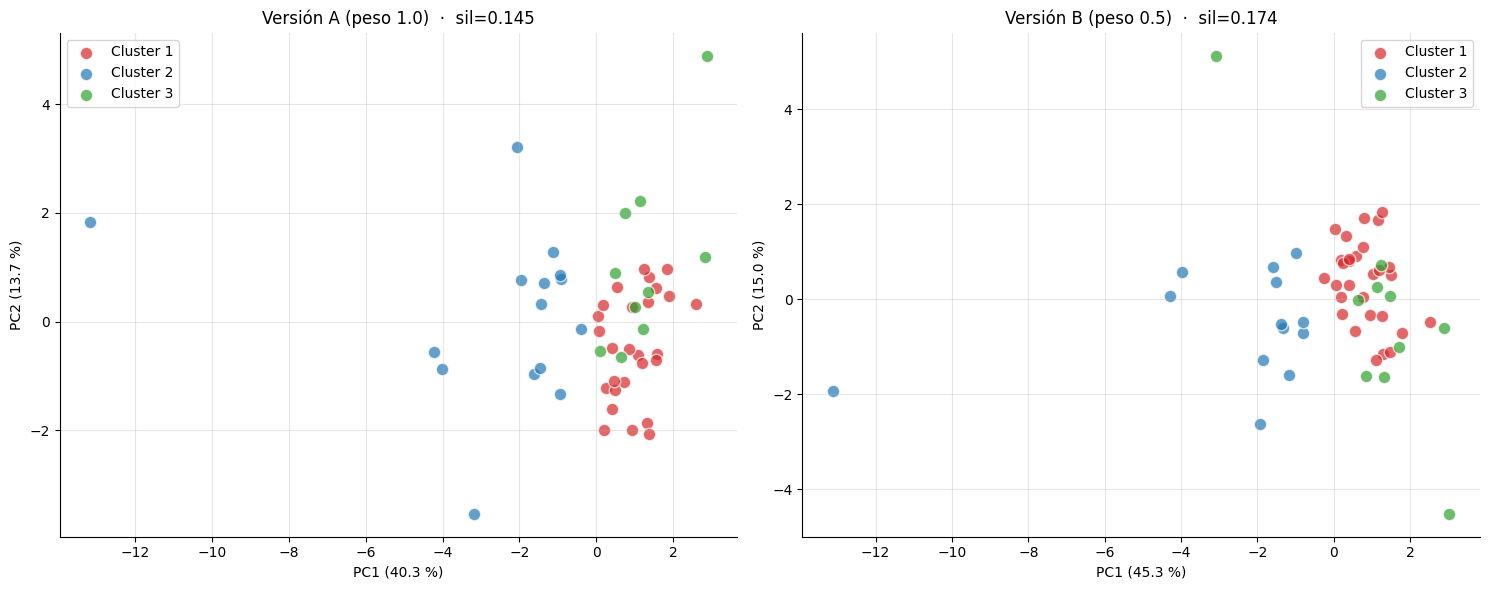

In [10]:
X_pca_A = pca_A.transform(X_A)
X_pca_B = pca_B.transform(X_B)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = ["tab:red", "tab:blue", "tab:green"]

for k in range(3):
    mask_A = df_imp["cluster_gmm_A"] == k
    axes[0].scatter(X_pca_A[mask_A, 0], X_pca_A[mask_A, 1], c=palette[k], label=f"Cluster {k+1}", s=80, alpha=0.7, edgecolor="white")
    mask_B = df_imp["cluster_gmm_B"] == k
    axes[1].scatter(X_pca_B[mask_B, 0], X_pca_B[mask_B, 1], c=palette[k], label=f"Cluster {k+1}", s=80, alpha=0.7, edgecolor="white")

axes[0].set_xlabel(f"PC1 ({pca_A.explained_variance_ratio_[0]*100:.1f} %)")
axes[0].set_ylabel(f"PC2 ({pca_A.explained_variance_ratio_[1]*100:.1f} %)")
axes[0].set_title(f"Versión A (peso 1.0)  ·  sil={sil_gmm_A:.3f}")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_xlabel(f"PC1 ({pca_B.explained_variance_ratio_[0]*100:.1f} %)")
axes[1].set_ylabel(f"PC2 ({pca_B.explained_variance_ratio_[1]*100:.1f} %)")
axes[1].set_title(f"Versión B (peso 0.5)  ·  sil={sil_gmm_B:.3f}")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 6.2 Perfil de los clusters — versión A

In [11]:
perfil_A = df_imp.copy()
medianas_A = perfil_A.groupby("cluster_gmm_A")[FEATURES_CONT].median().T
medianas_A.columns = [f"Cluster {c+1}" for c in medianas_A.columns]
print("Versión A (peso 1.0) — mediana de variables continuas:\n")
print(medianas_A.round(3).to_string())
print("\n\nVersión A — proporción de bancos que ofrecen cada producto:\n")
oferta_A = perfil_A.groupby("cluster_gmm_A")[FEATURES_BIN].mean().T
oferta_A.columns = [f"Cluster {c+1}" for c in oferta_A.columns]
print(oferta_A.round(2).to_string())

Versión A (peso 1.0) — mediana de variables continuas:

                         Cluster 1  Cluster 2  Cluster 3
log_activo                  21.511     18.416     20.046
prestamos_sobre_activo      34.562     21.873     23.250
titulos_sobre_activo         0.264      0.266      0.235
depositos_sobre_activo      66.488     60.142     45.400
patrimonio_sobre_activo      0.214      0.233      0.257
roa                          3.083     -2.328      3.226
liquidez                    20.449     24.335     23.549
eficiencia                  42.746     80.155     30.267
cartera_irregular            3.207      4.283      0.555
log_activo_por_empleado     14.218     13.196     14.755


Versión A — proporción de bancos que ofrecen cada producto:

                            Cluster 1  Cluster 2  Cluster 3
ofrece_hipoteca                  0.78       0.20        0.1
hipoteca_uva                     0.70       0.20        0.0
ofrece_personal                  1.00       0.87        0.3
ofrece_prendar

### 6.3 Perfil de los clusters — versión B

In [12]:
medianas_B = perfil_A.groupby("cluster_gmm_B")[FEATURES_CONT].median().T
medianas_B.columns = [f"Cluster {c+1}" for c in medianas_B.columns]
print("Versión B (peso 0.5) — mediana de variables continuas:\n")
print(medianas_B.round(3).to_string())
print("\n\nVersión B — proporción de bancos que ofrecen cada producto:\n")
oferta_B = perfil_A.groupby("cluster_gmm_B")[FEATURES_BIN].mean().T
oferta_B.columns = [f"Cluster {c+1}" for c in oferta_B.columns]
print(oferta_B.round(2).to_string())

Versión B (peso 0.5) — mediana de variables continuas:

                         Cluster 1  Cluster 2  Cluster 3
log_activo                  21.325     18.253     19.787
prestamos_sobre_activo      33.164     21.873     27.447
titulos_sobre_activo         0.264      0.266      0.257
depositos_sobre_activo      67.367     60.142     42.644
patrimonio_sobre_activo      0.200      0.255      0.306
roa                          2.643     -2.328      5.180
liquidez                    21.172     20.492     23.549
eficiencia                  43.779     81.535     34.952
cartera_irregular            2.503      4.283      0.692
log_activo_por_empleado     14.220     13.196     14.308


Versión B — proporción de bancos que ofrecen cada producto:

                            Cluster 1  Cluster 2  Cluster 3
ofrece_hipoteca                  0.69       0.23        0.2
hipoteca_uva                     0.62       0.23        0.1
ofrece_personal                  0.93       0.85        0.5
ofrece_prendar

### 6.4 Bancos por cluster — ambas versiones

In [13]:
for ver, col in [("A (peso 1.0)", "cluster_gmm_A"), ("B (peso 0.5)", "cluster_gmm_B")]:
    print(f"\n{'#'*66}\nVERSIÓN {ver}\n{'#'*66}")
    for c in sorted(df_imp[col].unique()):
        sub = df_imp[df_imp[col] == c]
        print(f"\n  Cluster {c+1}  ({len(sub)} bancos)")
        for _, row in sub.iterrows():
            tag = {"publico": "PUB", "privado_nacional": "PRI", "extranjero": "EXT"}.get(row["tipo_entidad"], "???")
            print(f"    [{tag}]  {row['nombre_banco'][:40]}")


##################################################################
VERSIÓN A (peso 1.0)
##################################################################

  Cluster 1  (27 bancos)
    [PRI]  BANCO DE GALICIA Y BUENOS AIRES S.A
    [PUB]  BANCO DE LA NACION ARGENTINA
    [PUB]  BANCO DE LA PROVINCIA DE BUENOS AIR
    [EXT]  INDUSTRIAL AND COMMERCIAL BANK OF C
    [EXT]  BANCO BBVA ARGENTINA S.A.
    [PUB]  BANCO DE LA PROVINCIA DE CORDOBA S.
    [PRI]  BANCO SUPERVIELLE S.A.
    [PUB]  BANCO DE LA CIUDAD DE BUENOS AIRES
    [PRI]  BANCO PATAGONIA S.A.
    [PUB]  BANCO HIPOTECARIO S.A.
    [PUB]  BANCO DE SAN JUAN S.A.
    [PUB]  BANCO MUNICIPAL DE ROSARIO
    [EXT]  BANCO SANTANDER ARGENTINA S.A.
    [PUB]  BANCO DEL CHUBUT S.A.
    [PUB]  BANCO DE SANTA CRUZ S.A.
    [PUB]  BANCO DE LA PAMPA SA
    [PUB]  BANCO DE CORRIENTES S.A.
    [PUB]  BANCO PROVINCIA DEL NEUQUÉN SOCIEDA
    [PRI]  BANCO CREDICOOP COOPERATIVO LIMITAD
    [PUB]  BANCO PROVINCIA DE TIERRA DEL FUEGO
    [PRI]  BANC

## 7. Comparación con notebooks 03 y 04

¿Las dos versiones de este notebook se parecen más al 03 (que tenía las binarias) o al 04 (que las descartaba)?

In [14]:
# Re-correr K-Means del notebook 03 para tener las etiquetas
FEATURES_03 = FEATURES_CONT + FEATURES_BIN
X_03 = StandardScaler().fit_transform(df_imp[FEATURES_03])
km_03 = KMeans(n_clusters=3, random_state=SEED, n_init=100)
df_imp["cluster_03"] = km_03.fit_predict(X_03)
sil_03 = silhouette_score(X_03, df_imp["cluster_03"])

# Re-correr GMM del notebook 04 (solo 10 continuas + log + Robust)
df_cont_04 = df_imp[FEATURES_CONT].copy()
for v in LOG_VARS:
    df_cont_04[v] = np.log1p(df_cont_04[v])
X_04 = RobustScaler().fit_transform(df_cont_04)
gmm_04 = GaussianMixture(n_components=3, covariance_type="full", random_state=SEED, n_init=20)
df_imp["cluster_04_gmm"] = gmm_04.fit_predict(X_04)
sil_04_gmm = silhouette_score(X_04, df_imp["cluster_04_gmm"])

print(f"{'Modelo':<55} {'Silhouette':>12}")
print("-" * 68)
print(f"{'Notebook 03 — K-Means k=3 (21 feat + StandardScaler)':<55} {sil_03:>12.3f}")
print(f"{'Notebook 04 — GMM k=3 (10 cont + log + Robust)':<55} {sil_04_gmm:>12.3f}")
print(f"{'Notebook 05 — K-Means k=3 Versión A (peso 1.0)':<55} {sil_km_A:>12.3f}")
print(f"{'Notebook 05 — K-Means k=3 Versión B (peso 0.5)':<55} {sil_km_B:>12.3f}")
print(f"{'Notebook 05 — GMM k=3 Versión A (peso 1.0)':<55} {sil_gmm_A:>12.3f}")
print(f"{'Notebook 05 — GMM k=3 Versión B (peso 0.5)':<55} {sil_gmm_B:>12.3f}")

Modelo                                                    Silhouette
--------------------------------------------------------------------
Notebook 03 — K-Means k=3 (21 feat + StandardScaler)           0.243
Notebook 04 — GMM k=3 (10 cont + log + Robust)                 0.262
Notebook 05 — K-Means k=3 Versión A (peso 1.0)                 0.219
Notebook 05 — K-Means k=3 Versión B (peso 0.5)                 0.249
Notebook 05 — GMM k=3 Versión A (peso 1.0)                     0.145
Notebook 05 — GMM k=3 Versión B (peso 0.5)                     0.174


In [15]:
def compare_partitions(name_a, lab_a, name_b, lab_b):
    ari = adjusted_rand_score(lab_a, lab_b)
    nmi = normalized_mutual_info_score(lab_a, lab_b)
    return ari, nmi

pares = [
    ("GMM A (peso 1.0)", "cluster_gmm_A", "Notebook 03 K-Means", "cluster_03"),
    ("GMM A (peso 1.0)", "cluster_gmm_A", "Notebook 04 GMM",     "cluster_04_gmm"),
    ("GMM B (peso 0.5)", "cluster_gmm_B", "Notebook 03 K-Means", "cluster_03"),
    ("GMM B (peso 0.5)", "cluster_gmm_B", "Notebook 04 GMM",     "cluster_04_gmm"),
    ("GMM A (peso 1.0)", "cluster_gmm_A", "GMM B (peso 0.5)",    "cluster_gmm_B"),
]

print(f"{'Comparación':<55} {'ARI':>7} {'NMI':>7}")
print("-" * 71)
for name_a, col_a, name_b, col_b in pares:
    ari, nmi = compare_partitions(name_a, df_imp[col_a], name_b, df_imp[col_b])
    print(f"{name_a + ' vs ' + name_b:<55} {ari:>7.3f} {nmi:>7.3f}")

Comparación                                                 ARI     NMI
-----------------------------------------------------------------------
GMM A (peso 1.0) vs Notebook 03 K-Means                   0.594   0.500
GMM A (peso 1.0) vs Notebook 04 GMM                       0.358   0.465
GMM B (peso 0.5) vs Notebook 03 K-Means                   0.427   0.294
GMM B (peso 0.5) vs Notebook 04 GMM                       0.419   0.452
GMM A (peso 1.0) vs GMM B (peso 0.5)                      0.737   0.669


### 7.1 ¿Aparecen los bancos digitales como cluster?

In [16]:
DIGITALES = ["BRUBANK", "UALA", "VOII", "DINO"]

mask_digi = df_imp["nombre_banco"].str.upper().str.contains("|".join(DIGITALES), na=False)
print(f"Bancos identificados como digitales/fintech: {mask_digi.sum()}\n")

for col, label in [("cluster_gmm_A", "Versión A (peso 1.0)"),
                    ("cluster_gmm_B", "Versión B (peso 0.5)"),
                    ("cluster_03", "Notebook 03 K-Means"),
                    ("cluster_04_gmm", "Notebook 04 GMM")]:
    asignaciones = df_imp.loc[mask_digi, [col, "nombre_banco"]]
    print(f"\n{label}:")
    print(asignaciones.to_string(index=False))

Bancos identificados como digitales/fintech: 4


Versión A (peso 1.0):
 cluster_gmm_A     nombre_banco
             1   BRUBANK S.A.U.
             1  BANCO VOII S.A.
             1 UALA BANK S.A.U.
             1  BANCO DINO S.A.

Versión B (peso 0.5):
 cluster_gmm_B     nombre_banco
             1   BRUBANK S.A.U.
             1  BANCO VOII S.A.
             1 UALA BANK S.A.U.
             1  BANCO DINO S.A.

Notebook 03 K-Means:
 cluster_03     nombre_banco
          1   BRUBANK S.A.U.
          0  BANCO VOII S.A.
          2 UALA BANK S.A.U.
          1  BANCO DINO S.A.

Notebook 04 GMM:
 cluster_04_gmm     nombre_banco
              0   BRUBANK S.A.U.
              0  BANCO VOII S.A.
              0 UALA BANK S.A.U.
              0  BANCO DINO S.A.


## 8. Conclusiones del notebook 05

*Esta sección se completa con los números reales una vez ejecutado el notebook.*

**Preguntas que respondemos**:

1. **¿Cuál ponderación da mejor estructura?** Comparar silhouette de Versión A vs Versión B.
2. **¿Recuperamos la dimensión de oferta?** Mirar loadings: ¿las binarias aparecen en los primeros componentes?
3. **¿Los bancos digitales (Brubank, Uala, Voii, Dino) quedan agrupados?** Ese fue el hallazgo emergente del notebook 04 — chequear si se mantiene cuando reincorporamos la oferta.
4. **¿La partición se parece más al 03 o al 04?** ARI alto con el 03 → recuperamos la estructura previa; ARI alto con el 04 → mantenemos el cambio metodológico.
5. **¿GMM aporta sobre K-Means en este espacio mixto?** Comparar las dos columnas de silhouette.